# Stage 3: Network Stability Across Size, Shape, and Data Source

This notebook is organised to test **different network sizes and shapes**, keep the synthetic set to **3 clear families**, and then compare that synthetic picture against the **original empirical data**.

The workflow has three parts:

1. **Synthetic size/shape sweep** using three graph families: `ring`, `random`, and `modular`
2. **Empirical-scale replica test** where those synthetic families are rebuilt at the same 78-node scale as the data and compared with the empirical structural matrix
3. **Empirical fit test** against the control and glioma PLI matrices already stored in `data/`

That gives us a simple narrative:

- do the Hopf dynamics behave similarly across a few qualitatively different synthetic networks?
- when we rebuild those synthetic networks at the same scale as the real data, do they look anything like the empirical case?
- does the actual empirical structural matrix produce a better match to the empirical PLI targets than the synthetic stand-ins?

The defaults are still moderate so the notebook stays practical to run, but the code is written so that you can scale the experiments up later.


In [13]:
import os
import sys
from pathlib import Path
from itertools import combinations

ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))

import numpy as np
import matplotlib.pyplot as plt

if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

FIG_DIR = ROOT / "figures" / "hopf model" / "network stability"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from hopf_model import random_initial_conditions, simulate_hopf
from signal_processing import compute_phase, compute_pli

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
RNG = np.random.default_rng(7)


## Helpers

The helpers below keep the notebook focused on the comparisons rather than the plumbing:

- graph generators for the three synthetic families
- normalization and summary utilities so different sizes are comparable
- repeated-simulation wrappers to measure initial-condition stability
- empirical-scale generators that rebuild synthetic networks at the same node count as the data


In [ ]:
def upper_triangle_values(matrix):
    idx = np.triu_indices_from(matrix, k=1)
    return matrix[idx]


def nonzero_upper_triangle_values(matrix):
    values = upper_triangle_values(np.asarray(matrix, dtype=float))
    return values[np.abs(values) > 0]


def matrix_correlation(a, b):
    x = upper_triangle_values(np.asarray(a, dtype=float))
    y = upper_triangle_values(np.asarray(b, dtype=float))
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan
    if np.allclose(x.std(), 0.0) or np.allclose(y.std(), 0.0):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def pairwise_consistency(matrices):
    scores = []
    for a, b in combinations(matrices, 2):
        score = matrix_correlation(a, b)
        if np.isfinite(score):
            scores.append(score)
    if not scores:
        return np.nan
    return float(np.mean(scores))


def edge_density(W):
    upper = upper_triangle_values(np.asarray(W, dtype=float))
    return float(np.mean(np.abs(upper) > 0))


def normalize_weights(W, method="spectral"):
    W = np.asarray(W, dtype=float)
    W = W.copy()
    np.fill_diagonal(W, 0.0)
    if method == "max":
        scale = np.max(np.abs(W))
    elif method == "row":
        row_sums = np.sum(np.abs(W), axis=1)
        scale = np.max(row_sums)
    elif method == "spectral":
        eigvals = np.linalg.eigvalsh(W)
        scale = np.max(np.abs(eigvals))
    else:
        raise ValueError(f"Unknown normalization method: {method}")
    if not np.isfinite(scale) or scale == 0:
        return W
    return W / scale


def ring_network(n, weight=1.0):
    W = np.zeros((n, n))
    for i in range(n):
        W[i, (i - 1) % n] = weight
        W[i, (i + 1) % n] = weight
    return W


def erdos_renyi_network(n, p=0.2, rng=None, weighted=True):
    rng = np.random.default_rng(rng)
    mask = rng.uniform(size=(n, n)) < p
    mask = np.triu(mask, k=1)
    if weighted:
        weights = rng.uniform(0.2, 1.0, size=(n, n))
        W = np.where(mask, weights, 0.0)
    else:
        W = mask.astype(float)
    W = W + W.T
    return W


def modular_network(n, modules=3, p_in=0.7, p_out=0.08, rng=None):
    rng = np.random.default_rng(rng)
    groups = np.array_split(np.arange(n), modules)
    W = np.zeros((n, n))
    for g in groups:
        for i in g:
            for j in g:
                if i < j and rng.uniform() < p_in:
                    W[i, j] = rng.uniform(0.4, 1.0)
    for gi, gj in combinations(groups, 2):
        for i in gi:
            for j in gj:
                if rng.uniform() < p_out:
                    W[i, j] = rng.uniform(0.1, 0.5)
    W = W + W.T
    return W


def sample_weighted_graph_from_mask(mask, weight_bank, rng=None):
    rng = np.random.default_rng(rng)
    W = np.zeros(mask.shape, dtype=float)
    edge_count = int(np.count_nonzero(mask))
    if edge_count > 0:
        sampled = rng.choice(weight_bank, size=edge_count, replace=True)
        W[mask] = sampled
    W = W + W.T
    return W


def density_matched_random_network(reference_W, rng=None):
    rng = np.random.default_rng(rng)
    n = reference_W.shape[0]
    density = edge_density(reference_W)
    weight_bank = nonzero_upper_triangle_values(reference_W)
    mask = np.triu(rng.uniform(size=(n, n)) < density, k=1)
    return normalize_weights(
        sample_weighted_graph_from_mask(mask, weight_bank, rng=rng)
    )


def density_matched_modular_network(reference_W, modules=4, rng=None):
    rng = np.random.default_rng(rng)
    n = reference_W.shape[0]
    density = edge_density(reference_W)
    weight_bank = nonzero_upper_triangle_values(reference_W)
    groups = np.array_split(np.arange(n), modules)
    mask = np.zeros((n, n), dtype=bool)

    p_in = min(0.75, max(0.18, density * 2.8))
    p_out = min(0.18, max(0.01, density * 0.35))

    for g in groups:
        for i in g:
            for j in g:
                if i < j and rng.uniform() < p_in:
                    mask[i, j] = True
    for gi, gj in combinations(groups, 2):
        for i in gi:
            for j in gj:
                if rng.uniform() < p_out:
                    mask[i, j] = True

    if not np.any(mask):
        return density_matched_random_network(reference_W, rng=rng)
    return normalize_weights(
        sample_weighted_graph_from_mask(mask, weight_bank, rng=rng)
    )


def make_topology(name, n, rng=None):
    rng = np.random.default_rng(rng)
    if name == "ring":
        W = ring_network(n)
    elif name == "random":
        p = min(0.35, max(0.08, 3.0 / max(n - 1, 1)))
        W = erdos_renyi_network(n, p=p, rng=rng)
    elif name == "modular":
        W = modular_network(n, modules=min(4, max(2, n // 10 or 2)), rng=rng)
    else:
        raise ValueError(f"Unknown topology: {name}")

    if not np.any(W):
        W = ring_network(n)
    return normalize_weights(W)


def make_empirical_scale_topology(name, reference_W, rng=None):
    reference_W = np.asarray(reference_W, dtype=float)
    n = reference_W.shape[0]
    if name == "ring":
        return normalize_weights(ring_network(n))
    if name == "random":
        return density_matched_random_network(reference_W, rng=rng)
    if name == "modular":
        return density_matched_modular_network(reference_W, rng=rng)
    if name == "empirical":
        return normalize_weights(reference_W)
    raise ValueError(f"Unknown empirical-scale topology: {name}")


def load_empirical_frequency_bank(path):
    raw = np.genfromtxt(path, delimiter=",", skip_header=1)
    if raw.ndim == 1:
        values = raw[1:]
    else:
        values = raw[:, 1:]
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    return values


def sample_frequency_vector(n, rng=None, mode="alpha_jitter", empirical_bank=None):
    rng = np.random.default_rng(rng)
    if mode == "alpha_jitter":
        hz = rng.normal(loc=10.0, scale=0.8, size=n)
    elif mode == "empirical_bank":
        if empirical_bank is None or len(empirical_bank) == 0:
            raise ValueError("empirical_bank mode requires a non-empty empirical bank")
        hz = rng.choice(empirical_bank, size=n, replace=True)
    elif mode == "smooth_gradient":
        base = np.linspace(8.5, 10.5, n)
        hz = base + rng.normal(scale=0.15, size=n)
    else:
        raise ValueError(f"Unknown frequency mode: {mode}")
    hz = np.clip(hz, 8.0, 12.0)
    return hz


def simulate_pli_matrix(
    W, K, lam, freq_hz, C=20.0, seed=None, t_total=8.0, t_discard=1.5, fs=300
):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]
    omega = 2 * np.pi * np.asarray(freq_hz, dtype=float)
    z0 = random_initial_conditions(n, rng=seed)
    _, x, _ = simulate_hopf(
        n,
        W,
        K,
        lam,
        C,
        omega,
        z0,
        t_total=t_total,
        t_discard=t_discard,
        fs=fs,
    )
    phases = compute_phase(x, fs=fs)
    pli = compute_pli(phases)
    return pli


def repeated_simulation_summary(
    W,
    K,
    lam,
    repeats=3,
    freq_mode="alpha_jitter",
    empirical_bank=None,
    base_seed=0,
    t_total=8.0,
    t_discard=1.5,
    fs=300,
):
    plis = []
    for rep in range(repeats):
        seed = base_seed + rep
        freq_hz = sample_frequency_vector(
            W.shape[0],
            rng=seed,
            mode=freq_mode,
            empirical_bank=empirical_bank,
        )
        pli = simulate_pli_matrix(
            W,
            K=K,
            lam=lam,
            freq_hz=freq_hz,
            seed=seed,
            t_total=t_total,
            t_discard=t_discard,
            fs=fs,
        )
        plis.append(pli)
    return {
        "mean_pli": np.mean(plis, axis=0),
        "consistency": pairwise_consistency(plis),
        "mean_strength": float(
            np.mean([upper_triangle_values(p).mean() for p in plis])
        ),
        "n_repeats": repeats,
    }


def evaluate_empirical_fit(
    W,
    target_fc,
    K_values,
    lam_values,
    repeats=3,
    empirical_bank=None,
    freq_mode="empirical_bank",
    t_total=8.0,
    t_discard=1.5,
    fs=300,
):
    fit = np.full((len(lam_values), len(K_values)), np.nan)
    stability = np.full_like(fit, np.nan)

    for i, lam in enumerate(lam_values):
        for j, K in enumerate(K_values):
            plis = []
            scores = []
            for rep in range(repeats):
                seed = 1000 + 100 * i + 10 * j + rep
                freq_hz = sample_frequency_vector(
                    W.shape[0],
                    rng=seed,
                    mode=freq_mode,
                    empirical_bank=empirical_bank,
                )
                pli = simulate_pli_matrix(
                    W,
                    K=K,
                    lam=lam,
                    freq_hz=freq_hz,
                    seed=seed,
                    t_total=t_total,
                    t_discard=t_discard,
                    fs=fs,
                )
                plis.append(pli)
                scores.append(matrix_correlation(pli, target_fc))
            fit[i, j] = np.nanmean(scores)
            stability[i, j] = pairwise_consistency(plis)
    return fit, stability

## 1. Synthetic networks: three shapes across a few sizes

To keep the experiment readable, we use exactly **three** synthetic graph families:

- **ring**: regular local coupling
- **random**: irregular connectivity with no obvious mesoscale structure
- **modular**: clustered connectivity, which is the most brain-like of the three synthetic options

We then repeat each simulation several times with new initial conditions and frequency draws.

Two summary metrics matter here:

- **IC stability**: correlation between FC matrices across repeated runs
- **SC-FC alignment**: correlation between structural weights and the mean simulated PLI matrix

This is the direct response to the "different size and shape networks" idea before touching the empirical data.


In [ ]:
SYNTHETIC_SIZES = [10, 30, 78]
SYNTHETIC_TOPOLOGIES = ["ring", "random", "modular"]
SYNTHETIC_K_VALUES = [0.5, 1.5, 3.0]
SYNTHETIC_LAM = 1.0
SYNTHETIC_REPEATS = 3
FAST_SIM_KWARGS = dict(t_total=6.5, t_discard=1.5, fs=250)

In [ ]:
synthetic_results = []

for topology in SYNTHETIC_TOPOLOGIES:
    for n in SYNTHETIC_SIZES:
        W = make_topology(topology, n, rng=RNG.integers(0, 1_000_000))
        for K in SYNTHETIC_K_VALUES:
            summary = repeated_simulation_summary(
                W,
                K=K,
                lam=SYNTHETIC_LAM,
                repeats=SYNTHETIC_REPEATS,
                base_seed=10_000 + 100 * n + int(10 * K),
                **FAST_SIM_KWARGS,
            )
            synthetic_results.append(
                {
                    "topology": topology,
                    "n": n,
                    "K": K,
                    "consistency": summary["consistency"],
                    "strength": summary["mean_strength"],
                    "sc_fc": matrix_correlation(W, summary["mean_pli"]),
                }
            )

print(f"Completed {len(synthetic_results)} synthetic experiments.")

Completed 27 synthetic experiments.


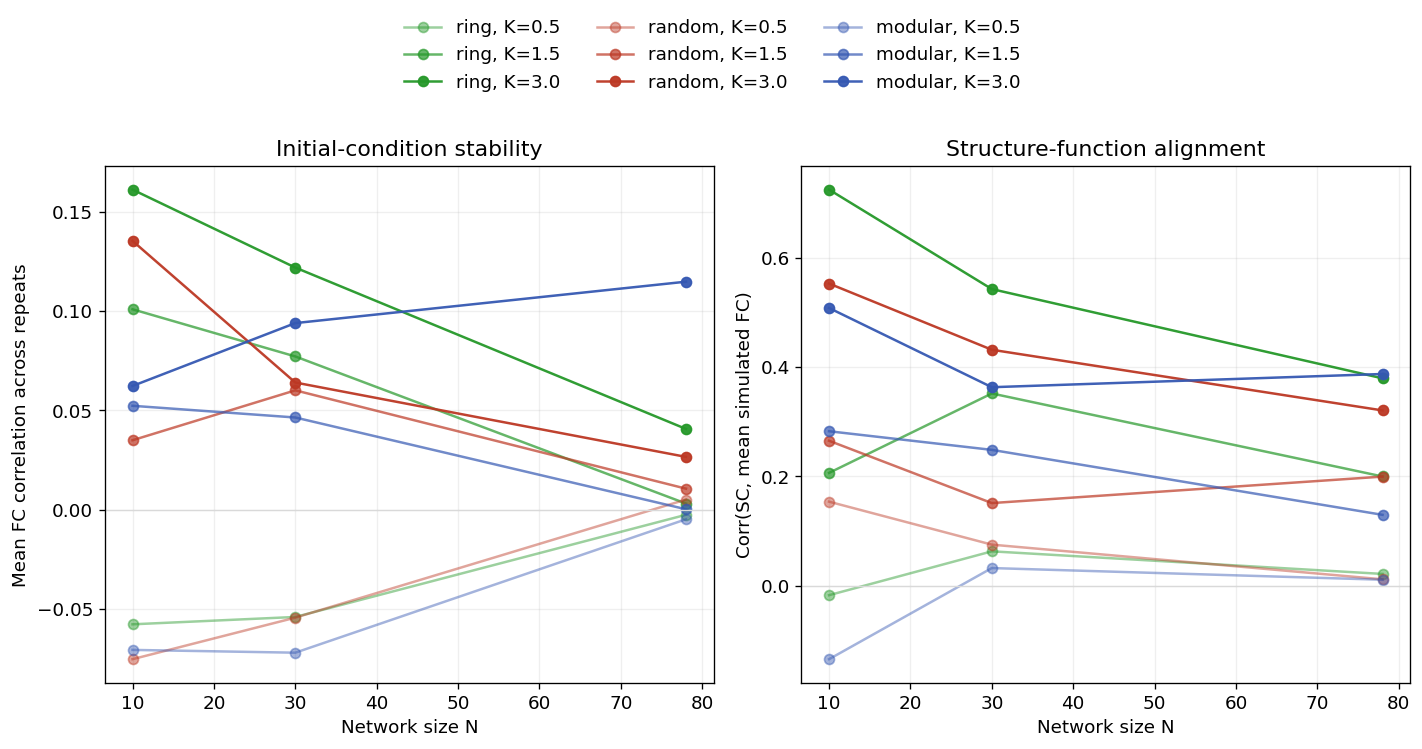

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True)
colors = {
    "ring": "#259829",
    "random": "#bc3824",
    "modular": "#3558b2",
}

for topology in SYNTHETIC_TOPOLOGIES:
    for K in SYNTHETIC_K_VALUES:
        subset = [
            r for r in synthetic_results if r["topology"] == topology and r["K"] == K
        ]
        subset = sorted(subset, key=lambda r: r["n"])
        n_vals = [r["n"] for r in subset]
        consistency = [r["consistency"] for r in subset]
        sc_fc = [r["sc_fc"] for r in subset]
        label = f"{topology}, K={K}"
        alpha = {0.5: 0.45, 1.5: 0.7, 3.0: 0.95}[K]
        axes[0].plot(
            n_vals,
            consistency,
            marker="o",
            lw=1.5,
            color=colors[topology],
            alpha=alpha,
            label=label,
        )
        axes[1].plot(
            n_vals,
            sc_fc,
            marker="o",
            lw=1.5,
            color=colors[topology],
            alpha=alpha,
            label=label,
        )

axes[0].set(
    title="Initial-condition stability",
    xlabel="Network size N",
    ylabel="Mean FC correlation across repeats",
)
axes[1].set(
    title="Structure-function alignment",
    xlabel="Network size N",
    ylabel="Corr(SC, mean simulated FC)",
)
for ax in axes:
    ax.axhline(0, color="0.85", lw=0.8)
    ax.grid(alpha=0.2)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    ncols=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.12),
    frameon=False,
)
fig.tight_layout(rect=[0, 0.08, 1, 1.1])

### Inspect one synthetic example

This quick visual check makes it easy to see one member of the synthetic family before moving to the empirical-scale comparison.


IC stability: -0.019
SC-FC alignment: 0.266


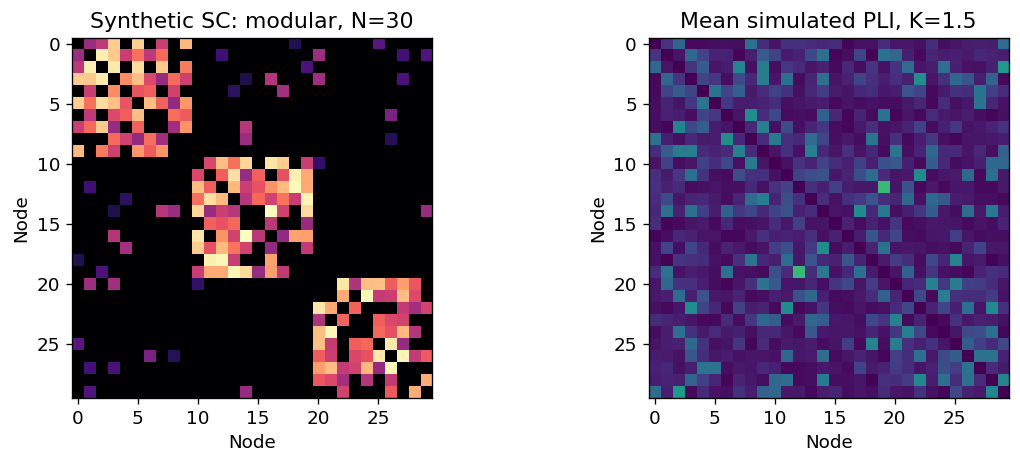

In [ ]:
EXAMPLE_TOPOLOGY = "modular"
EXAMPLE_N = 30
EXAMPLE_K = 1.5
EXAMPLE_LAM = 1.0

W_example = make_topology(EXAMPLE_TOPOLOGY, EXAMPLE_N, rng=123)
example_summary = repeated_simulation_summary(
    W_example,
    K=EXAMPLE_K,
    lam=EXAMPLE_LAM,
    repeats=3,
    base_seed=1234,
    **FAST_SIM_KWARGS,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(W_example, cmap="magma")
axes[0].set_title(f"Synthetic SC: {EXAMPLE_TOPOLOGY}, N={EXAMPLE_N}")
axes[1].imshow(example_summary["mean_pli"], cmap="viridis", vmin=0, vmax=1)
axes[1].set_title(f"Mean simulated PLI, K={EXAMPLE_K}")
for ax in axes:
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")
fig.tight_layout()

print(f"IC stability: {example_summary['consistency']:.3f}")
print(
    f"SC-FC alignment: {matrix_correlation(W_example, example_summary['mean_pli']):.3f}"
)

## 2. Empirical-scale replica test

Before fitting the real structural matrix directly, we rebuild the synthetic families at the same **78-node scale** as the empirical network.

This is the closest thing to a synthetic replica of the empirical setup:

- same number of nodes as the data
- empirical frequency bank for `omega_i` sampling
- one extra comparison case using the actual empirical structural matrix itself

If the empirical structural matrix is doing something meaningful, it should usually outperform the synthetic stand-ins when compared against the empirical PLI targets.


In [ ]:
SC_EMP = normalize_weights(
    np.loadtxt(ROOT / "data" / "structural_connectivity_matrix.csv", delimiter=",")
)
CONTROL_PLI = np.loadtxt(ROOT / "data" / "control_PLI_raw.csv", delimiter=",")
GLIOMA_PLI = np.loadtxt(ROOT / "data" / "glioma_PLI_raw.csv", delimiter=",")
FREQ_BANK = load_empirical_frequency_bank(ROOT / "data" / "exp_frequencies.csv")

print("SC shape:", SC_EMP.shape)
print("Control PLI shape:", CONTROL_PLI.shape)
print("Glioma PLI shape:", GLIOMA_PLI.shape)
print(f"Empirical SC density: {edge_density(SC_EMP):.3f}")
print(f"Frequency bank size: {len(FREQ_BANK)}")
print(f"Frequency range: {FREQ_BANK.min():.2f} to {FREQ_BANK.max():.2f} Hz")

SC shape: (78, 78)
Control PLI shape: (78, 78)
Glioma PLI shape: (78, 78)
Empirical SC density: 0.162
Frequency bank size: 3132
Frequency range: 4.57 to 23.78 Hz


In [ ]:
REPLICA_TOPOLOGIES = ["ring", "random", "modular", "empirical"]
REPLICA_K_VALUES = [0.5, 1.5, 3.0]
REPLICA_LAM = 1.0
REPLICA_REPEATS = 3
REPLICA_SIM_KWARGS = dict(t_total=6.5, t_discard=1.5, fs=250)

replica_results = []

for topology in REPLICA_TOPOLOGIES:
    W_replica = make_empirical_scale_topology(
        topology, SC_EMP, rng=RNG.integers(0, 1_000_000)
    )
    for K in REPLICA_K_VALUES:
        summary = repeated_simulation_summary(
            W_replica,
            K=K,
            lam=REPLICA_LAM,
            repeats=REPLICA_REPEATS,
            empirical_bank=FREQ_BANK,
            freq_mode="empirical_bank",
            base_seed=30_000 + int(100 * K),
            **REPLICA_SIM_KWARGS,
        )
        replica_results.append(
            {
                "topology": topology,
                "K": K,
                "consistency": summary["consistency"],
                "strength": summary["mean_strength"],
                "fit_control": matrix_correlation(summary["mean_pli"], CONTROL_PLI),
                "fit_glioma": matrix_correlation(summary["mean_pli"], GLIOMA_PLI),
                "sc_similarity": matrix_correlation(W_replica, SC_EMP),
            }
        )

print(f"Completed {len(replica_results)} empirical-scale replica experiments.")

Completed 12 empirical-scale replica experiments.


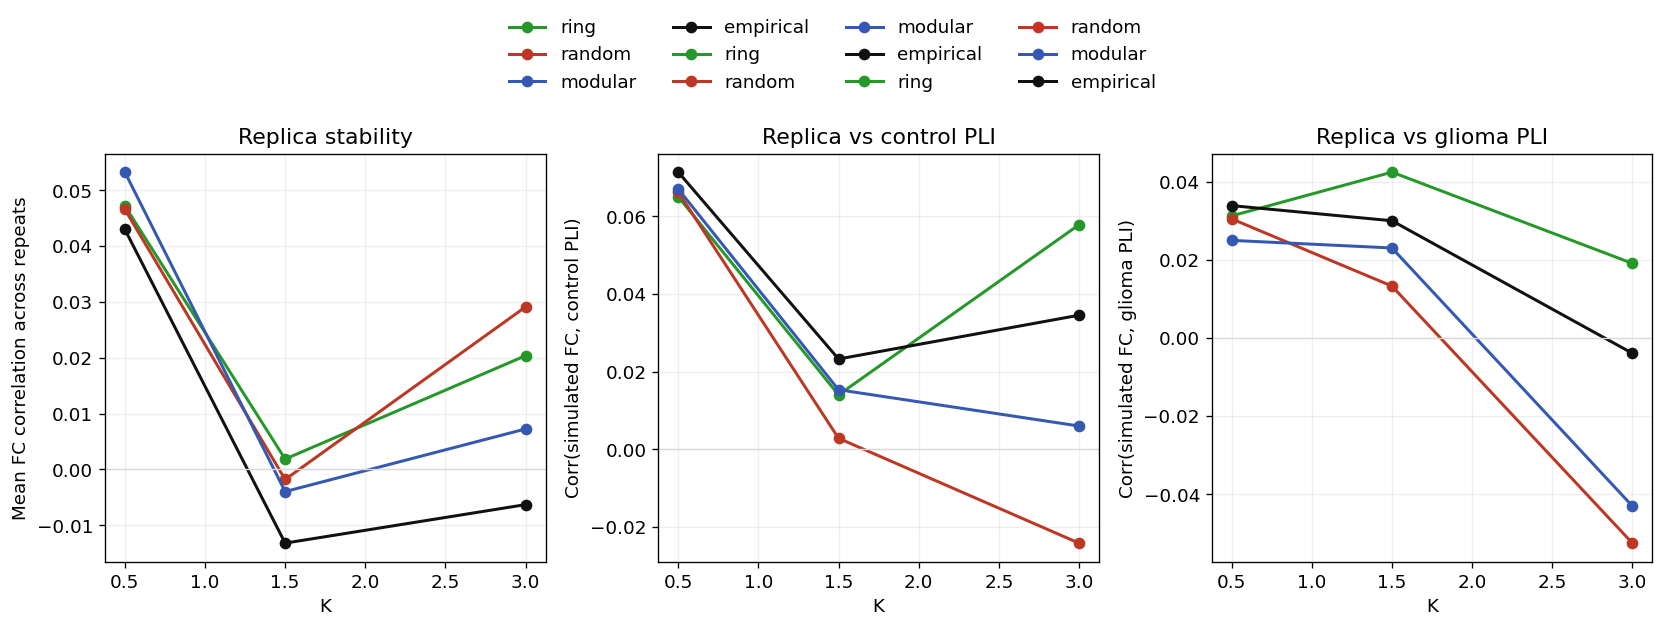

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True)
colors = {
    "ring": "#259829",
    "random": "#bc3824",
    "modular": "#3558b2",
    "empirical": "#111111",
}

for topology in REPLICA_TOPOLOGIES:
    subset = [r for r in replica_results if r["topology"] == topology]
    subset = sorted(subset, key=lambda r: r["K"])
    k_vals = [r["K"] for r in subset]
    axes[0].plot(
        k_vals,
        [r["consistency"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )
    axes[1].plot(
        k_vals,
        [r["fit_control"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )
    axes[2].plot(
        k_vals,
        [r["fit_glioma"] for r in subset],
        marker="o",
        lw=1.8,
        color=colors[topology],
        label=topology,
    )

axes[0].set(
    title="Replica stability", xlabel="K", ylabel="Mean FC correlation across repeats"
)
axes[1].set(
    title="Replica vs control PLI", xlabel="K", ylabel="Corr(simulated FC, control PLI)"
)
axes[2].set(
    title="Replica vs glioma PLI", xlabel="K", ylabel="Corr(simulated FC, glioma PLI)"
)
for ax in axes:
    ax.axhline(0, color="0.85", lw=0.8)
    ax.grid(alpha=0.2)

fig.legend(ncols=4, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout(rect=[0, 0.02, 1, 1.02])

## 3. Empirical fit test

Now we use the actual empirical structural matrix as the simulator input and score the resulting PLI against the empirical control and glioma targets.

A small caution still applies: the frequency table is not obviously aligned node-by-node with the 78-node structural matrix, so for now we use it as an **empirical frequency bank** and sample plausible frequencies from that distribution. If a confirmed node mapping becomes available, this can be replaced with a fixed node-level `omega_i` vector.


In [ ]:
EMP_K_VALUES = np.array([0.5, 1.5, 3.0, 5.0])
EMP_LAM_VALUES = np.array([0.4, 1.0, 1.6])
EMP_REPEATS = 3
EMP_SIM_KWARGS = dict(t_total=8.0, t_discard=1.5, fs=300)

control_fit, control_stability = evaluate_empirical_fit(
    SC_EMP,
    CONTROL_PLI,
    EMP_K_VALUES,
    EMP_LAM_VALUES,
    repeats=EMP_REPEATS,
    empirical_bank=FREQ_BANK,
    **EMP_SIM_KWARGS,
)
glioma_fit, glioma_stability = evaluate_empirical_fit(
    SC_EMP,
    GLIOMA_PLI,
    EMP_K_VALUES,
    EMP_LAM_VALUES,
    repeats=EMP_REPEATS,
    empirical_bank=FREQ_BANK,
    **EMP_SIM_KWARGS,
)

joint_fit = np.minimum(control_fit, glioma_fit)
joint_stability = np.minimum(control_stability, glioma_stability)

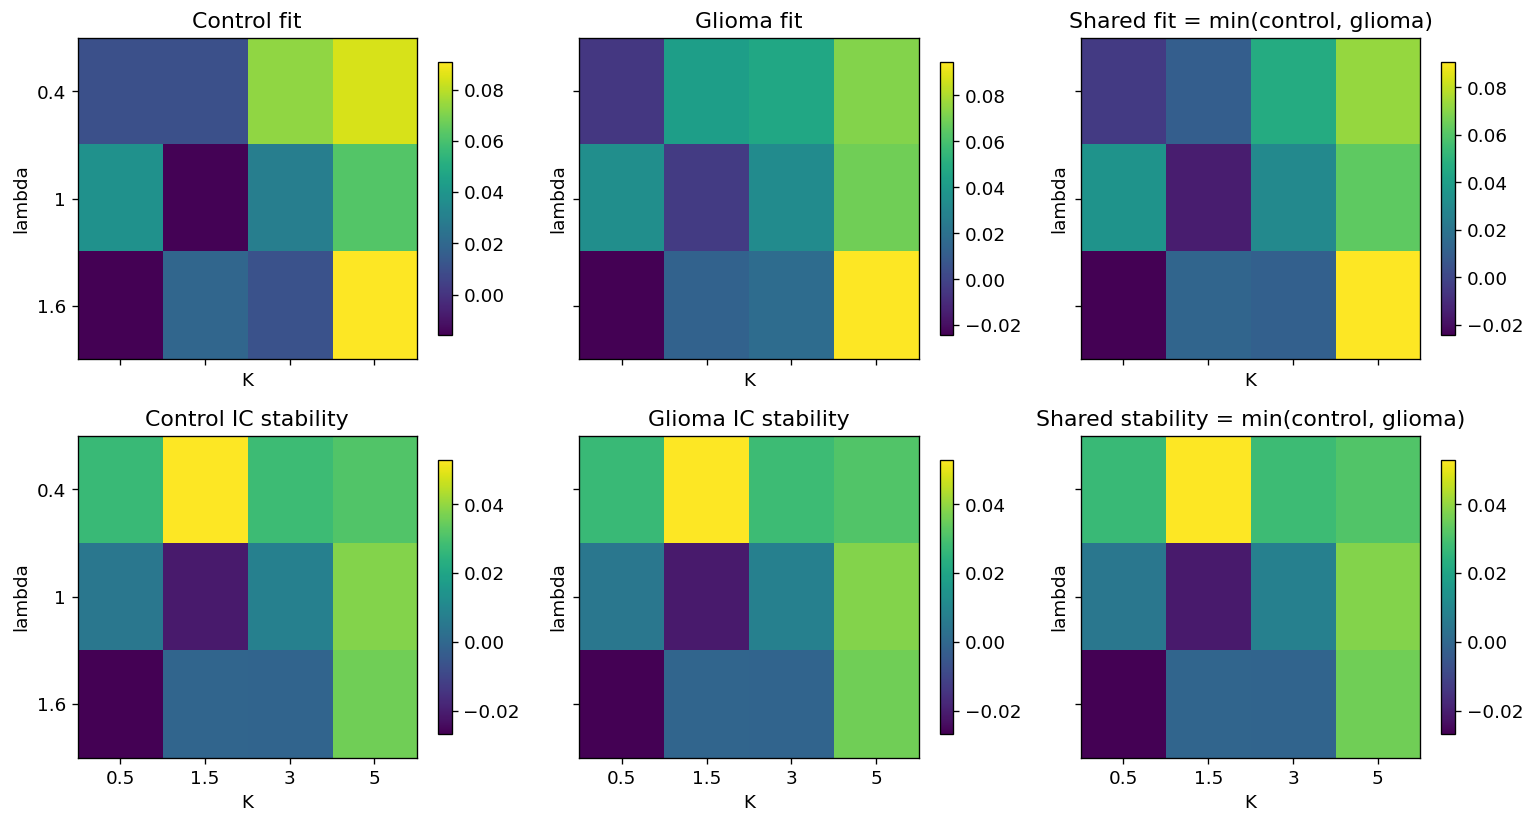

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
panels = [
    (control_fit, "Control fit"),
    (glioma_fit, "Glioma fit"),
    (joint_fit, "Shared fit = min(control, glioma)"),
    (control_stability, "Control IC stability"),
    (glioma_stability, "Glioma IC stability"),
    (joint_stability, "Shared stability = min(control, glioma)"),
]

for ax, (matrix, title) in zip(axes.flat, panels):
    im = ax.imshow(matrix, cmap="viridis", aspect="auto")
    ax.set_title(title)
    ax.set_xticks(range(len(EMP_K_VALUES)), labels=[f"{k:g}" for k in EMP_K_VALUES])
    ax.set_yticks(
        range(len(EMP_LAM_VALUES)), labels=[f"{lam:g}" for lam in EMP_LAM_VALUES]
    )
    ax.set_xlabel("K")
    ax.set_ylabel("lambda")
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.tight_layout()

Best shared-fit parameters: K=5, lambda=1.6
Control fit: 0.091
Glioma fit: 0.095
Shared stability: 0.035


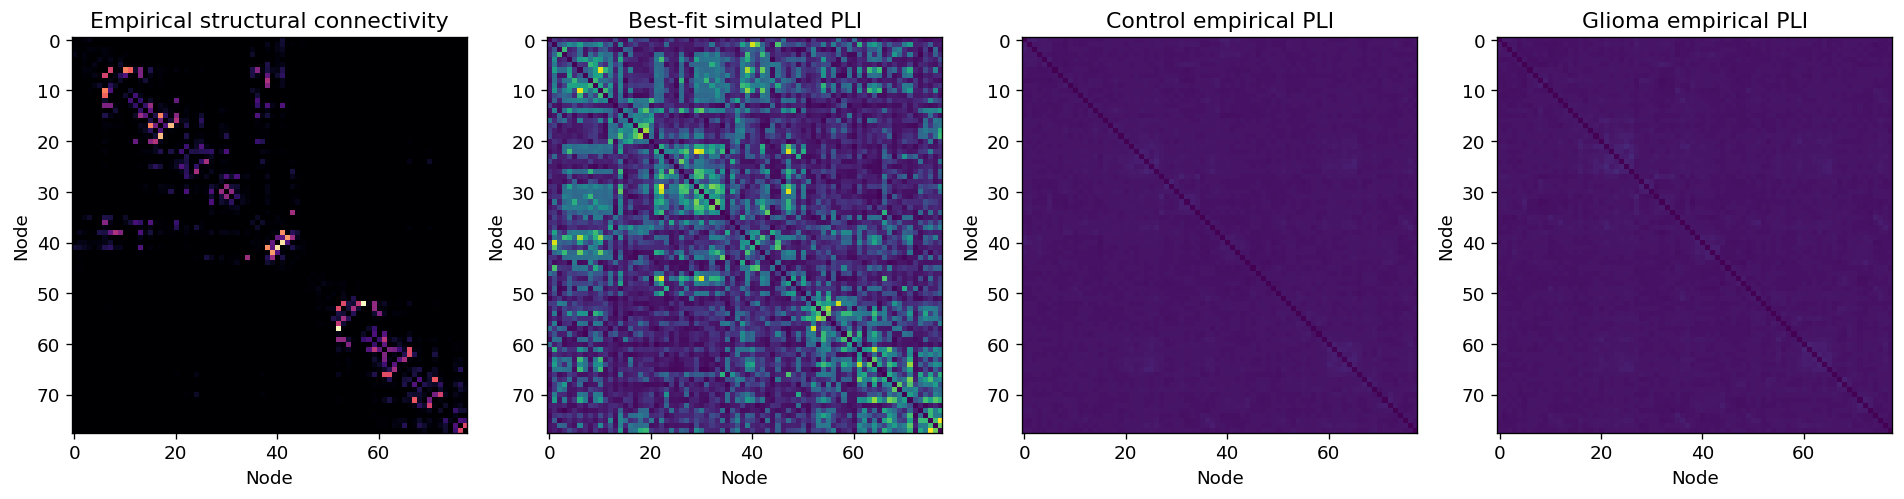

In [ ]:
best_idx = np.unravel_index(np.nanargmax(joint_fit), joint_fit.shape)
best_lam = EMP_LAM_VALUES[best_idx[0]]
best_K = EMP_K_VALUES[best_idx[1]]

print(f"Best shared-fit parameters: K={best_K:g}, lambda={best_lam:g}")
print(f"Control fit: {control_fit[best_idx]:.3f}")
print(f"Glioma fit: {glioma_fit[best_idx]:.3f}")
print(f"Shared stability: {joint_stability[best_idx]:.3f}")

best_summary = repeated_simulation_summary(
    SC_EMP,
    K=best_K,
    lam=best_lam,
    repeats=EMP_REPEATS,
    empirical_bank=FREQ_BANK,
    freq_mode="empirical_bank",
    base_seed=90_000,
    **EMP_SIM_KWARGS,
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(SC_EMP, cmap="magma")
axes[0].set_title("Empirical structural connectivity")
axes[1].imshow(best_summary["mean_pli"], cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Best-fit simulated PLI")
axes[2].imshow(CONTROL_PLI, cmap="viridis", vmin=0, vmax=1)
axes[2].set_title("Control empirical PLI")
axes[3].imshow(GLIOMA_PLI, cmap="viridis", vmin=0, vmax=1)
axes[3].set_title("Glioma empirical PLI")
for ax in axes:
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")
fig.tight_layout()

## Useful interpretations:

- **Synthetic sweep**: are the conclusions robust across three clearly different graph shapes and across small, medium, and empirical-scale networks?
- **Empirical-scale replica**: once the synthetic families are rebuilt at 78 nodes, does the real structural matrix still look special relative to the stand-ins?
- **Empirical fit**: is there a broad region of parameters that fits both control and glioma data, or only a narrow fine-tuned corner?

